In [1]:
# ==============================================================================
# CELDA 1: Evaluación con embeddings usando LazyClassifier SIN SMOTE
# (Solo class_weight='balanced' en modelos que lo soporten)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_no_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model} (SIN SMOTE)")
    print(f"{'='*80}")
    
    try:
        # Cargar datos desde el manifest
        X_mat, y_mat, groups = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        
        # Convertir a DataFrame / Series para manejar los índices
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
        groups = np.array(groups)
        
        print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
        
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
    
    # Inyectar class_weight='balanced' en los modelos de LazyClassifier que lo soporten
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)
    for name, model in clf.models.items():
        if hasattr(model, 'class_weight'):
            model.class_weight = 'balanced'

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # Entrenar LazyClassifier directamente en el fold SIN SMOTE
        models_fold, _ = clf.fit(X_tr, X_val, y_tr, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        # Resumen del promedio de los 5 folds para este modelo de embeddings
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model}:")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_no_smote.append(cv_summary)

if resultados_globales_no_smote:
    res_final_no_smote = pd.concat(resultados_globales_no_smote, ignore_index=True)
    res_final_no_smote = res_final_no_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (SIN SMOTE)")
    print(f"{'='*80}")
    print(res_final_no_smote.head(15).to_string(index=False))


EVALUANDO EMBEDDINGS DEL MODELO: xlsr-300m (SIN SMOTE)


20:50:58 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Shape de X: (79, 1024), Shape de y: (79,)


20:51:00 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:51:01 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:51:02 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:51:03 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:51:04 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:51:05 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:51:06 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para xlsr-300m:
Embedding_Model                       Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m                 BernoulliNB  0.585083           0.576409  0.600353  0.538284 0.566417
      xlsr-300m PassiveAggressiveClassifier  0.590667           0.537485  0.601466  0.518710 0.525629
      xlsr-300m          LogisticRegression  0.642667           0.536621  0.629528  0.517374 0.542682
      xlsr-300m         ExtraTreeClassifier  0.612417           0.521015  0.611440  0.510260 0.521015
      xlsr-300m                  Perceptron  0.579000           0.527864  0.589103  0.507030 0.520242

EVALUANDO EMBEDDINGS DEL MODELO: xlsr-53 (SIN SMOTE)


...


Top 5 clasificadores para wavlm-large:
Embedding_Model                Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
    wavlm-large           GaussianNB  0.604917           0.558864  0.615714  0.536972 0.570042
    wavlm-large   AdaBoostClassifier  0.677500           0.541970  0.652454  0.532367 0.533758
    wavlm-large          BernoulliNB  0.593333           0.552348  0.606276  0.531689 0.574542
    wavlm-large      NearestCentroid  0.587000           0.541394  0.598967  0.521030 0.580360
    wavlm-large KNeighborsClassifier  0.697667           0.530470  0.653496  0.514830 0.530761

EVALUANDO EMBEDDINGS DEL MODELO: hubert-large (SIN SMOTE)


20:57:31 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Shape de X: (79, 1024), Shape de y: (79,)


20:57:32 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:57:33 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:57:34 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:57:35 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:57:36 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:57:37 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:57:38 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para hubert-large:
Embedding_Model                Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
   hubert-large    RidgeClassifierCV  0.663083           0.545394  0.647285  0.535719 0.556553
   hubert-large      RidgeClassifier  0.656750           0.539409  0.642036  0.530060 0.562144
   hubert-large KNeighborsClassifier  0.687250           0.528545  0.648737  0.514028 0.493242
   hubert-large  ExtraTreeClassifier  0.609583           0.520545  0.611103  0.513160 0.520545
   hubert-large           GaussianNB  0.563500           0.532470  0.577691  0.504393 0.534917

RANKING GLOBAL DE MODELOS DE EMBEDDINGS (SIN SMOTE)
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust   KNeighborsClassifier  0.744667           0.640879  0.729639  0.639047 0.666235
wav2vec2-large-robust   ExtraTreesClassifier  0.759750           0.619273  0.726237  0.618107 0.684314
wav2vec2-large-robust      

In [2]:
# ==============================================================================
# CELDA 2: Evaluación con embeddings usando LazyClassifier CON SMOTE
# (SMOTE aplicado SOLO en el conjunto de TRAIN del CV)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
import importlib, subprocess, sys

from imblearn.over_sampling import SMOTE


warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model} (CON SMOTE en TRAIN)")
    print(f"{'='*80}")
    
    try:
        X_mat, y_mat, groups = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
        groups = np.array(groups)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # SMOTE solo en el set de Entrenamiento para evitar data leakage
        k = min(5, int(y_tr.value_counts().min()) - 1)
        if k >= 1:
            X_tr, y_tr = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr, y_tr)
        
        models_fold, _ = clf.fit(X_tr, X_val, y_tr, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (CON SMOTE):")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_smote.append(cv_summary)

if resultados_globales_smote:
    res_final_smote = pd.concat(resultados_globales_smote, ignore_index=True)
    res_final_smote = res_final_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (CON SMOTE)")
    print(f"{'='*80}")
    print(res_final_smote.head(15).to_string(index=False))



EVALUANDO EMBEDDINGS DEL MODELO: xlsr-300m (CON SMOTE en TRAIN)


20:58:41 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:58:43 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:58:44 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:58:46 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:58:48 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:58:49 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
20:58:51 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para xlsr-300m (CON SMOTE):
Embedding_Model                       Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m                  GaussianNB  0.641750           0.566091  0.646379  0.558148 0.575731
      xlsr-300m                 BernoulliNB  0.611583           0.569652  0.621044  0.543707 0.569814
      xlsr-300m             NearestCentroid  0.591417           0.556879  0.604976  0.531434 0.565477
      xlsr-300m          LogisticRegression  0.629167           0.539561  0.624981  0.522802 0.539682
      xlsr-300m PassiveAggressiveClassifier  0.613583           0.534197  0.615578  0.519920 0.541879

EVALUANDO EMBEDDINGS DEL MODELO: xlsr-53 (CON SMOTE en TRAIN)


21:00:21 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:00:23 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:00:25 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:00:26 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:00:28 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:00:30 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:00:31 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para xlsr-53 (CON SMOTE):
Embedding_Model                      Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
        xlsr-53                 GaussianNB  0.594083           0.552864  0.606205  0.530957 0.571981
        xlsr-53            NearestCentroid  0.552917           0.543424  0.572205  0.509244 0.556792
        xlsr-53        ExtraTreeClassifier  0.601583           0.514212  0.602288  0.505129 0.514212
        xlsr-53 LinearDiscriminantAnalysis  0.585833           0.514758  0.593085  0.499428 0.517848
        xlsr-53                BernoulliNB  0.560583           0.513652  0.574644  0.494490 0.520739

EVALUANDO EMBEDDINGS DEL MODELO: whisper-large-encoder (CON SMOTE en TRAIN)


...


Top 5 clasificadores para wav2vec2-large-robust (CON SMOTE):
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust   ExtraTreesClassifier  0.763500           0.636136  0.736439  0.637252 0.666580
wav2vec2-large-robust RandomForestClassifier  0.735917           0.630606  0.718442  0.625406 0.674451
wav2vec2-large-robust                    SVC  0.717250           0.621152  0.705395  0.613686 0.638303
wav2vec2-large-robust                  NuSVC  0.723333           0.615227  0.708263  0.613465 0.622894
wav2vec2-large-robust            BernoulliNB  0.656667           0.648348  0.662695  0.604016 0.619280

EVALUANDO EMBEDDINGS DEL MODELO: wavlm-large (CON SMOTE en TRAIN)


21:05:52 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:05:54 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:05:56 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:05:57 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:05:59 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:06:01 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:06:03 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para wavlm-large (CON SMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
    wavlm-large             GaussianNB  0.666750           0.588803  0.666169  0.576951 0.581587
    wavlm-large            BernoulliNB  0.623500           0.571364  0.633090  0.553779 0.588163
    wavlm-large        NearestCentroid  0.600833           0.558167  0.613052  0.537127 0.585061
    wavlm-large   ExtraTreesClassifier  0.723917           0.551818  0.667960  0.526722 0.582803
    wavlm-large RandomForestClassifier  0.693750           0.543318  0.655283  0.524724 0.549951

EVALUANDO EMBEDDINGS DEL MODELO: hubert-large (CON SMOTE en TRAIN)


21:07:36 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:07:37 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:07:39 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:07:41 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:07:43 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:07:44 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:07:46 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para hubert-large (CON SMOTE):
Embedding_Model             Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
   hubert-large   RidgeClassifier  0.659250           0.543409  0.645415  0.534545 0.562455
   hubert-large               SVC  0.683417           0.545212  0.654383  0.531446 0.494159
   hubert-large        GaussianNB  0.619167           0.548697  0.621614  0.530848 0.559580
   hubert-large RidgeClassifierCV  0.655417           0.539591  0.641666  0.530079 0.558947
   hubert-large         LinearSVC  0.650333           0.528000  0.633455  0.516435 0.538326

RANKING GLOBAL DE MODELOS DE EMBEDDINGS (CON SMOTE)
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust   ExtraTreesClassifier  0.763500           0.636136  0.736439  0.637252 0.666580
wav2vec2-large-robust RandomForestClassifier  0.735917           0.630606  0.718442  0.625406 0.674451
wav2vec2-large-robust            

In [3]:
# ==============================================================================
# CELDA: Evaluación con embeddings usando LazyClassifier 
# Pipeline: StandardScaler -> SMOTE (solo en el conjunto de TRAIN del CV) -> LazyClassifier
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_scaler_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model}")
    print(f"Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier")
    print(f"{'='*80}")
    
    try:
        X_mat, y_mat, groups = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
        groups = np.array(groups)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr_raw, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val_raw, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # 1. Escalar (entrenando solo en X_tr)
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_raw)
        X_val_sc = scaler.transform(X_val_raw)
        
        # 2. SMOTE solo en el set de Entrenamiento transformado para evitar data leakage
        k = min(5, int(y_tr.value_counts().min()) - 1)
        if k >= 1:
            X_tr_sm, y_tr_sm = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr_sc, y_tr)
        else:
            X_tr_sm, y_tr_sm = X_tr_sc, y_tr
            
        # Convertir a DataFrames para LazyPredict
        X_tr_df = pd.DataFrame(X_tr_sm, columns=X.columns)
        X_val_df = pd.DataFrame(X_val_sc, columns=X.columns)
        
        models_fold, _ = clf.fit(X_tr_df, X_val_df, y_tr_sm, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (StandardScaler + SMOTE):")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_scaler_smote.append(cv_summary)

if resultados_globales_scaler_smote:
    res_final_scaler_smote = pd.concat(resultados_globales_scaler_smote, ignore_index=True)
    res_final_scaler_smote = res_final_scaler_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (StandardScaler -> SMOTE)")
    print(f"{'='*80}")
    print(res_final_scaler_smote.head(15).to_string(index=False))



EVALUANDO EMBEDDINGS DEL MODELO: xlsr-300m
Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier


21:09:20 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:09:22 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:09:23 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:09:24 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:09:26 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:09:27 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:09:29 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para xlsr-300m (StandardScaler + SMOTE):
Embedding_Model              Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m         GaussianNB  0.635750           0.554818  0.639017  0.546979 0.572951
      xlsr-300m        BernoulliNB  0.604250           0.563636  0.614124  0.536702 0.572136
      xlsr-300m LogisticRegression  0.631583           0.545152  0.628096  0.527863 0.540303
      xlsr-300m                SVC  0.677167           0.531091  0.648761  0.522389 0.537674
      xlsr-300m    NearestCentroid  0.580250           0.544803  0.595714  0.521555 0.564758

EVALUANDO EMBEDDINGS DEL MODELO: xlsr-53
Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier


21:10:51 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:10:53 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:10:54 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:10:56 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:10:57 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:10:59 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:11:00 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para xlsr-53 (StandardScaler + SMOTE):
Embedding_Model                      Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
        xlsr-53                 GaussianNB  0.588833           0.545621  0.601187  0.524598 0.556625
        xlsr-53        ExtraTreeClassifier  0.589000           0.506076  0.594473  0.498897 0.506076
        xlsr-53 LinearDiscriminantAnalysis  0.594833           0.511394  0.597553  0.498306 0.510409
        xlsr-53            NearestCentroid  0.542833           0.533591  0.560793  0.498124 0.547670
        xlsr-53              SGDClassifier  0.622083           0.511273  0.609822  0.497160 0.519326

EVALUANDO EMBEDDINGS DEL MODELO: whisper-large-encoder
Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier


...


Top 5 clasificadores para wav2vec2-large-robust (StandardScaler + SMOTE):
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust   ExtraTreesClassifier  0.762083           0.637394  0.735736  0.637427 0.670477
wav2vec2-large-robust RandomForestClassifier  0.736750           0.624970  0.717054  0.621382 0.654034
wav2vec2-large-robust                    SVC  0.723417           0.626682  0.710940  0.619816 0.647909
wav2vec2-large-robust            BernoulliNB  0.665500           0.657364  0.672227  0.613958 0.622318
wav2vec2-large-robust                  NuSVC  0.720917           0.616167  0.707259  0.613354 0.625970

EVALUANDO EMBEDDINGS DEL MODELO: wavlm-large
Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier


21:15:46 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:15:47 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:15:49 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:15:50 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:15:52 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:15:53 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:15:55 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para wavlm-large (StandardScaler + SMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
    wavlm-large             GaussianNB  0.660167           0.577970  0.659138  0.566794 0.582284
    wavlm-large            BernoulliNB  0.628500           0.577455  0.638189  0.560201 0.587489
    wavlm-large RandomForestClassifier  0.710000           0.567106  0.677655  0.558613 0.554606
    wavlm-large        NearestCentroid  0.598417           0.557076  0.611033  0.535597 0.589701
    wavlm-large                    SVC  0.709750           0.549955  0.661423  0.525559 0.551871

EVALUANDO EMBEDDINGS DEL MODELO: hubert-large
Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier


21:17:16 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:17:18 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:17:19 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:17:21 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:17:22 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:17:24 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:17:25 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para hubert-large (StandardScaler + SMOTE):
Embedding_Model             Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
   hubert-large   RidgeClassifier  0.659250           0.543409  0.645415  0.534545 0.563235
   hubert-large RidgeClassifierCV  0.656750           0.542091  0.643296  0.532604 0.558114
   hubert-large        GaussianNB  0.616500           0.543470  0.619444  0.526785 0.553152
   hubert-large               SVC  0.674250           0.533773  0.644253  0.517971 0.488205
   hubert-large         LinearSVC  0.651667           0.528909  0.633871  0.516191 0.539326

RANKING GLOBAL DE MODELOS DE EMBEDDINGS (StandardScaler -> SMOTE)
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust   ExtraTreesClassifier  0.762083           0.637394  0.735736  0.637427 0.670477
wav2vec2-large-robust RandomForestClassifier  0.736750           0.624970  0.717054  0.621382 0.654034
wav2ve

In [4]:
# ==============================================================================
# CELDA 3: Evaluación con embeddings usando LazyClassifier CON BorderlineSMOTE
# (BorderlineSMOTE aplicado SOLO en el conjunto de TRAIN del CV)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
import importlib, subprocess, sys

from imblearn.over_sampling import BorderlineSMOTE


warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_borderline = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model} (CON BorderlineSMOTE en TRAIN)")
    print(f"{'='*80}")
    
    try:
        X_mat, y_mat, groups = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
        groups = np.array(groups)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # BorderlineSMOTE solo en el set de Entrenamiento para evitar data leakage
        min_class_count = int(y_tr.value_counts().min())
        k = min(5, min_class_count - 1)
        m = min(10, min_class_count - 1)
        
        if k >= 1 and m >= 1:
            try:
                smote = BorderlineSMOTE(random_state=42, k_neighbors=k, m_neighbors=m)
                X_tr, y_tr = smote.fit_resample(X_tr, y_tr)
            except Exception as e:
                pass
        
        models_fold, _ = clf.fit(X_tr, X_val, y_tr, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (CON BorderlineSMOTE):")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_borderline.append(cv_summary)

if resultados_globales_borderline:
    res_final_borderline = pd.concat(resultados_globales_borderline, ignore_index=True)
    res_final_borderline = res_final_borderline.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (CON BorderlineSMOTE)")
    print(f"{'='*80}")
    print(res_final_borderline.head(15).to_string(index=False))



EVALUANDO EMBEDDINGS DEL MODELO: xlsr-300m (CON BorderlineSMOTE en TRAIN)


21:18:46 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:18:48 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:18:50 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:18:51 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:18:53 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:18:55 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:18:56 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para xlsr-300m (CON BorderlineSMOTE):
Embedding_Model                       Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m                  GaussianNB  0.635500           0.560182  0.640645  0.551274 0.572970
      xlsr-300m                 BernoulliNB  0.607750           0.565985  0.616757  0.538743 0.571371
      xlsr-300m          LogisticRegression  0.632833           0.546485  0.628692  0.528138 0.538174
      xlsr-300m PassiveAggressiveClassifier  0.616083           0.537455  0.617517  0.522237 0.541356
      xlsr-300m             NearestCentroid  0.586333           0.545288  0.599495  0.522223 0.566576

EVALUANDO EMBEDDINGS DEL MODELO: xlsr-53 (CON BorderlineSMOTE en TRAIN)


21:20:28 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:20:30 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:20:31 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:20:33 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:20:35 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:20:37 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:20:38 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para xlsr-53 (CON BorderlineSMOTE):
Embedding_Model                      Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
        xlsr-53                 GaussianNB  0.594083           0.552864  0.606205  0.530957 0.569027
        xlsr-53            NearestCentroid  0.553000           0.542333  0.572228  0.508728 0.552731
        xlsr-53        ExtraTreeClassifier  0.595417           0.509470  0.597891  0.501710 0.509470
        xlsr-53 LinearDiscriminantAnalysis  0.583250           0.511348  0.590788  0.496816 0.516705
        xlsr-53                BernoulliNB  0.560583           0.513652  0.574644  0.494490 0.518864

EVALUANDO EMBEDDINGS DEL MODELO: whisper-large-encoder (CON BorderlineSMOTE en TRAIN)


...


Top 5 clasificadores para wav2vec2-large-robust (CON BorderlineSMOTE):
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust   ExtraTreesClassifier  0.757167           0.632318  0.732613  0.634788 0.680242
wav2vec2-large-robust                    SVC  0.714500           0.625773  0.705883  0.617384 0.634098
wav2vec2-large-robust                  NuSVC  0.718167           0.614773  0.704291  0.610223 0.621780
wav2vec2-large-robust RandomForestClassifier  0.722750           0.604227  0.700759  0.594824 0.655197
wav2vec2-large-robust    ExtraTreeClassifier  0.654417           0.579727  0.654804  0.568472 0.579727

EVALUANDO EMBEDDINGS DEL MODELO: wavlm-large (CON BorderlineSMOTE en TRAIN)


21:25:57 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:25:59 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:26:00 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:26:02 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:26:04 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:26:05 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:26:07 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para wavlm-large (CON BorderlineSMOTE):
Embedding_Model                      Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
    wavlm-large                 GaussianNB  0.669167           0.593152  0.669662  0.581442 0.578947
    wavlm-large                BernoulliNB  0.621000           0.568530  0.630557  0.551316 0.589883
    wavlm-large            NearestCentroid  0.600833           0.558167  0.613183  0.537376 0.583523
    wavlm-large LinearDiscriminantAnalysis  0.615333           0.549348  0.619610  0.530964 0.544030
    wavlm-large     RandomForestClassifier  0.696083           0.544909  0.657412  0.527603 0.548761

EVALUANDO EMBEDDINGS DEL MODELO: hubert-large (CON BorderlineSMOTE en TRAIN)


21:27:39 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:27:40 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:27:42 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:27:44 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:27:46 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:27:48 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:27:49 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para hubert-large (CON BorderlineSMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
   hubert-large      RidgeClassifierCV  0.658083           0.543000  0.644336  0.533737 0.558129
   hubert-large        RidgeClassifier  0.658000           0.542500  0.644370  0.533482 0.560439
   hubert-large             GaussianNB  0.616583           0.548697  0.620795  0.531522 0.561712
   hubert-large                    SVC  0.678417           0.538545  0.649160  0.524382 0.491455
   hubert-large RandomForestClassifier  0.670833           0.535015  0.643051  0.519983 0.512595

RANKING GLOBAL DE MODELOS DE EMBEDDINGS (CON BorderlineSMOTE)
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust   ExtraTreesClassifier  0.757167           0.632318  0.732613  0.634788 0.680242
wav2vec2-large-robust                    SVC  0.714500           0.625773  0.705883  0

In [5]:
# ==============================================================================
# CELDA: Evaluación con embeddings usando LazyClassifier 
# Pipeline: StandardScaler -> BorderlineSMOTE (solo en el conjunto de TRAIN del CV) -> LazyClassifier
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import BorderlineSMOTE

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_scaler_borderline = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model}")
    print(f"Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier")
    print(f"{'='*80}")
    
    try:
        X_mat, y_mat, groups = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
        groups = np.array(groups)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr_raw, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val_raw, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # 1. Escalar (entrenando solo en X_tr)
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_raw)
        X_val_sc = scaler.transform(X_val_raw)
        
        # 2. BorderlineSMOTE solo en el set de Entrenamiento transformado para evitar data leakage
        min_class_count = int(y_tr.value_counts().min())
        k = min(5, min_class_count - 1)
        m = min(10, min_class_count - 1)
        
        if k >= 1 and m >= 1:
            try:
                smote = BorderlineSMOTE(random_state=42, k_neighbors=k, m_neighbors=m)
                X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_tr)
            except Exception as e:
                X_tr_sm, y_tr_sm = X_tr_sc, y_tr
        else:
            X_tr_sm, y_tr_sm = X_tr_sc, y_tr
            
        # Convertir a DataFrames para LazyPredict
        X_tr_df = pd.DataFrame(X_tr_sm, columns=X.columns)
        X_val_df = pd.DataFrame(X_val_sc, columns=X.columns)
        
        models_fold, _ = clf.fit(X_tr_df, X_val_df, y_tr_sm, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (StandardScaler + BorderlineSMOTE):")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_scaler_borderline.append(cv_summary)

if resultados_globales_scaler_borderline:
    res_final_scaler_borderline = pd.concat(resultados_globales_scaler_borderline, ignore_index=True)
    res_final_scaler_borderline = res_final_scaler_borderline.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS (StandardScaler -> BorderlineSMOTE)")
    print(f"{'='*80}")
    print(res_final_scaler_borderline.head(15).to_string(index=False))


EVALUANDO EMBEDDINGS DEL MODELO: xlsr-300m
Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier


21:29:21 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:29:23 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:29:24 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:29:26 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:29:27 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:29:29 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:29:30 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para xlsr-300m (StandardScaler + BorderlineSMOTE):
Embedding_Model              Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m         GaussianNB  0.640667           0.554152  0.641635  0.546809 0.567311
      xlsr-300m        BernoulliNB  0.602917           0.559894  0.612089  0.533332 0.575852
      xlsr-300m LogisticRegression  0.631667           0.543909  0.627128  0.526005 0.535894
      xlsr-300m    NearestCentroid  0.587750           0.548288  0.601901  0.525623 0.569822
      xlsr-300m          LinearSVC  0.625167           0.539167  0.621301  0.520603 0.540553

EVALUANDO EMBEDDINGS DEL MODELO: xlsr-53
Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier


21:30:52 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:30:53 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:30:55 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:30:56 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:30:57 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:30:59 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:31:00 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para xlsr-53 (StandardScaler + BorderlineSMOTE):
Embedding_Model                      Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
        xlsr-53                 GaussianNB  0.582500           0.540439  0.596238  0.520011 0.547311
        xlsr-53 LinearDiscriminantAnalysis  0.593583           0.517000  0.599158  0.503985 0.508235
        xlsr-53              SGDClassifier  0.635833           0.516242  0.619103  0.502852 0.529038
        xlsr-53            NearestCentroid  0.540083           0.529955  0.558006  0.495427 0.549136
        xlsr-53                BernoulliNB  0.559083           0.512455  0.574292  0.494087 0.532205

EVALUANDO EMBEDDINGS DEL MODELO: whisper-large-encoder
Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier


...


Top 5 clasificadores para wav2vec2-large-robust (StandardScaler + BorderlineSMOTE):
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust   ExtraTreesClassifier  0.774917           0.649788  0.748825  0.654354 0.676750
wav2vec2-large-robust RandomForestClassifier  0.735833           0.636167  0.720785  0.630054 0.666538
wav2vec2-large-robust                    SVC  0.718167           0.626227  0.709159  0.620893 0.651705
wav2vec2-large-robust                  NuSVC  0.720917           0.620515  0.708844  0.617016 0.623856
wav2vec2-large-robust            BernoulliNB  0.620333           0.628576  0.633247  0.579981 0.616239

EVALUANDO EMBEDDINGS DEL MODELO: wavlm-large
Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier


21:35:37 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:35:39 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:35:40 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:35:41 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:35:43 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:35:44 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:35:46 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para wavlm-large (StandardScaler + BorderlineSMOTE):
Embedding_Model                      Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
    wavlm-large                 GaussianNB  0.661500           0.577212  0.660095  0.566840 0.581242
    wavlm-large                BernoulliNB  0.623417           0.573030  0.633617  0.556575 0.588629
    wavlm-large     RandomForestClassifier  0.703750           0.560106  0.671190  0.550406 0.551061
    wavlm-large            NearestCentroid  0.597000           0.557333  0.610400  0.535861 0.589398
    wavlm-large LinearDiscriminantAnalysis  0.612583           0.541864  0.615833  0.524791 0.541182

EVALUANDO EMBEDDINGS DEL MODELO: hubert-large
Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier


21:37:05 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:37:07 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:37:08 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:37:10 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:37:11 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:37:12 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
21:37:14 [WARNING] lazypredict — High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Top 5 clasificadores para hubert-large (StandardScaler + BorderlineSMOTE):
Embedding_Model               Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
   hubert-large     RidgeClassifier  0.659333           0.543909  0.645247  0.534594 0.562402
   hubert-large   RidgeClassifierCV  0.658000           0.541409  0.643617  0.532069 0.559492
   hubert-large          GaussianNB  0.617750           0.547636  0.621700  0.530925 0.555114
   hubert-large ExtraTreeClassifier  0.613250           0.537091  0.617668  0.525173 0.537091
   hubert-large         BernoulliNB  0.611083           0.538727  0.613536  0.521651 0.551121

RANKING GLOBAL DE MODELOS (StandardScaler -> BorderlineSMOTE)
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust   ExtraTreesClassifier  0.774917           0.649788  0.748825  0.654354 0.676750
wav2vec2-large-robust RandomForestClassifier  0.735833           0.636167  0.720785  0.6300

In [6]:
# ==============================================================================
# EVALUACIÓN DE EMBEDDINGS: StandardScaler -> PCA (0.95) -> SMOTE -> Clasificador
# - Usa StratifiedKFold 
# - Pipeline aplicado correctamente: se ajusta (fit) en train, transforma val,
#   y luego SMOTE se aplica solo en train transformado.
# ==============================================================================

import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_pca_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS: {emb_model}")
    print(f"Pipeline: StandardScaler -> PCA(0.95) -> SMOTE (solo train) -> LazyClassifier")
    print(f"{'='*80}")
    
    try:
        X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # 1. Escalar (entrenando solo en X_tr)
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_val_sc = scaler.transform(X_val)
        
        # 2. PCA
        pca = PCA(n_components=15, random_state=42)
        X_tr_pca = pca.fit_transform(X_tr_sc)
        X_val_pca = pca.transform(X_val_sc)
        
        # 3. SMOTE solo en train
        k = min(5, int(y_tr.value_counts().min()) - 1)
        if k >= 1:
            X_tr_sm, y_tr_sm = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr_pca, y_tr)
        else:
            X_tr_sm, y_tr_sm = X_tr_pca, y_tr
            
        # Convertir a DataFrames
        X_tr_df = pd.DataFrame(X_tr_sm)
        X_val_df = pd.DataFrame(X_val_pca)
        
        # 4. Entrenar y predecir
        models_fold, _ = clf.fit(X_tr_df, X_val_df, y_tr_sm, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (PCA + SMOTE):")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_pca_smote.append(cv_summary)

if resultados_globales_pca_smote:
    res_final_pca_smote = pd.concat(resultados_globales_pca_smote, ignore_index=True)
    res_final_pca_smote = res_final_pca_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL FINAL (StandardScaler -> PCA 0.95 -> SMOTE -> LazyClassifier)")
    print(f"{'='*80}")
    print(res_final_pca_smote.head(15).to_string(index=False))


EVALUANDO EMBEDDINGS: xlsr-300m
Pipeline: StandardScaler -> PCA(0.95) -> SMOTE (solo train) -> LazyClassifier

Top 5 clasificadores para xlsr-300m (PCA + SMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m             GaussianNB  0.641583           0.543606  0.634594  0.531410 0.534902
      xlsr-300m            BernoulliNB  0.595833           0.535409  0.601003  0.514244 0.539674
      xlsr-300m RandomForestClassifier  0.673000           0.525318  0.642152  0.512703 0.509019
      xlsr-300m                    SVC  0.666750           0.517152  0.636487  0.505641 0.495386
      xlsr-300m                  NuSVC  0.654000           0.511697  0.628328  0.500881 0.496735

EVALUANDO EMBEDDINGS: xlsr-53
Pipeline: StandardScaler -> PCA(0.95) -> SMOTE (solo train) -> LazyClassifier

Top 5 clasificadores para xlsr-53 (PCA + SMOTE):
Embedding_Model               Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
  

## Top 3 modelos por ROC AUC (embeddings `wav2vec2-large-robust`)

Ranking obtenido a partir de los resultados de LazyClassifier en las celdas anteriores (SIN SMOTE, CON SMOTE, StandardScaler+SMOTE, BorderlineSMOTE, StandardScaler+BorderlineSMOTE, PCA+SMOTE). En todos los pipelines, `wav2vec2-large-robust` domina como el mejor modelo de embeddings.

| # | Clasificador | Mejor pipeline | ROC AUC |
|---|---|---|---|
| 1 | `ExtraTreesClassifier` | Sin SMOTE (class_weight='balanced') | 0.6843 |
| 2 | `RandomForestClassifier` | Con SMOTE (solo train) | 0.6745 |
| 3 | `KNeighborsClassifier` | StandardScaler → BorderlineSMOTE | 0.6668 |

`ExtraTreesClassifier` ya fue optimizado arriba (celdas de GridSearchCV y evaluación final). A continuación se optimizan `RandomForestClassifier` y `KNeighborsClassifier` con la misma metodología: GridSearchCV sobre el pipeline `StandardScaler → BorderlineSMOTE → Clasificador`, usando embeddings `wav2vec2-large-robust`.


In [6]:
# ==============================================================================
# CELDA: Grid Search CV para ExtraTreesClassifier
# Pipeline: ExtraTreesClassifier (SIN SMOTE, SIN escalado)
# Este fue el pipeline que obtuvo el mejor ROC AUC (0.6843) para este
# clasificador en la comparación de LazyClassifier (ver celda 1, SIN SMOTE)
# Embeddings: wav2vec2-large-robust
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesClassifier

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
EMB_MODEL = "wav2vec2-large-robust"

print(f"\n{'='*80}")
print(f"OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: ExtraTreesClassifier")
print(f"Pipeline: ExtraTreesClassifier (SIN SMOTE, SIN escalado)")
print(f"{'='*80}")

try:
    X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, EMB_MODEL, condition=CONDITION)
    X = pd.DataFrame(X_mat)
    y = pd.Series(y_mat)
    print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
except Exception as e:
    print(f"Error cargando los embeddings: {e}")
    sys.exit(1)

# Sin StandardScaler ni SMOTE/BorderlineSMOTE: el desbalance se maneja vía
# class_weight (incluido en la grilla), igual que en la comparación de LazyClassifier
pipeline = Pipeline([
    ('clf', ExtraTreesClassifier(random_state=42))
])

# Definir la grilla de hiperparámetros a buscar
param_grid = {
    # Tamaño del bosque — más árboles = más estable
    'clf__n_estimators': [100, 200, 300, 500],

    # El hiperparámetro MÁS influyente en ExtraTrees
    'clf__max_features': ['sqrt', 'log2', 0.2, 0.3, 0.5, None],

    # Profundidad: None = árboles completos (típico en ExtraTrees)
    'clf__max_depth': [None, 10, 20, 30, 50],

    # Regularización por hoja — más importante que min_samples_split
    'clf__min_samples_leaf': [1, 2, 3, 5],

    # Split mínimo — interactúa con min_samples_leaf
    'clf__min_samples_split': [2, 5, 10],

    # Pesos de clase — crítico con desbalance, ya que aquí no hay resampling
    'clf__class_weight': ['balanced', 'balanced_subsample', None],

    # Criterio de impureza — gini vs entropia en ExtraTrees puede variar
    'clf__criterion': ['gini', 'entropy']
}
# 4×6×5×4×3×3×2 = 8,640 combinaciones × 15 folds = 129,600 fits

# Para multiclase se construye un scorer explícito con labels fijos (igual que en la evaluación final).
classes   = np.unique(y)
is_binary = len(classes) == 2

if is_binary:
    roc_scorer = 'roc_auc'          # sklearn lo resuelve nativamente
else:
    _classes_fixed = classes.tolist()   # lista serializable para multiprocessing

    def _roc_auc_multiclass(y_true, y_prob):
        present = np.unique(y_true)
        if len(present) < len(_classes_fixed):
            return np.nan
        try:
            return roc_auc_score(
                y_true, y_prob,
                average='macro',
                multi_class='ovr',
                labels=_classes_fixed,
            )
        except Exception:
            return np.nan

    roc_scorer = make_scorer(_roc_auc_multiclass, needs_proba=True)

scoring = {
    'f1_macro': make_scorer(f1_score, average="macro", zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc':  roc_scorer,
}

# Configurar Validación Cruzada (3 repeticiones en lugar de 10 para agilizar la búsqueda)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

print("\nIniciando GridSearchCV. Esto puede tomar varios minutos de forma silenciosa...")
grid_search_et = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Optimizar basándose finalmente en ROC AUC
    cv=cv,
    n_jobs=-1,  # Usar todos los procesadores disponibles
    verbose=1,  # Te irá imprimiendo el progreso capa por capa
)

grid_search_et.fit(X, y)

print(f"\n{'='*80}")
print("RESULTADOS DE LA BÚSQUEDA")
print(f"{'='*80}")
print(f"Mejores Hiperparámetros:\n{grid_search_et.best_params_}")
print(f"Mejor score de validación (ROC AUC): {grid_search_et.best_score_:.4f}")

# Extraer el Top 5 de las mejores combinaciones
resultados_cv_et = pd.DataFrame(grid_search_et.cv_results_)
top_5_et = resultados_cv_et.sort_values(by="rank_test_roc_auc").head(5)

print("\nTop 5 configuraciones de Hiperparámetros:")
for idx, row in top_5_et.iterrows():
    print(f"\nRank {row['rank_test_roc_auc']}:")
    print(f"  ROC AUC:  {row['mean_test_roc_auc']:.4f} (±{row['std_test_roc_auc']:.4f})")
    print(f"  F1 Macro: {row['mean_test_f1_macro']:.4f} (±{row['std_test_f1_macro']:.4f})")
    print(f"  Accuracy: {row['mean_test_accuracy']:.4f} (±{row['std_test_accuracy']:.4f})")
    print(f"  Parámetros: {row['params']}")



OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: ExtraTreesClassifier
Pipeline: ExtraTreesClassifier (SIN SMOTE, SIN escalado)
Shape de X: (79, 1024), Shape de y: (79,)

Iniciando GridSearchCV. Esto puede tomar varios minutos de forma silenciosa...
Fitting 15 folds for each of 8640 candidates, totalling 129600 fits

RESULTADOS DE LA BÚSQUEDA
Mejores Hiperparámetros:
{'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Mejor score de validación (ROC AUC): 0.7559

Top 5 configuraciones de Hiperparámetros:

Rank 1:
  ROC AUC:  0.7559 (±0.0846)
  F1 Macro: 0.6464 (±0.1081)
  Accuracy: 0.7719 (±0.0683)
  Parámetros: {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 20


EVALUACIÓN FINAL (10 repeticiones x 5 folds)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: ExtraTreesClassifier (Parámetros Optimizados)
Shape de X: (79, 1024), Shape de y: (79,)
Hiperparámetros usados: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Iniciando Evaluación mediante cross_validate. Esto tomará algunos minutos...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 28 concurrent workers.



RESULTADOS FINALES DE LA EVALUACIÓN
F1 Macro Promedio: 0.6203 (±0.0996)
Accuracy Promedio:  0.7595 (±0.0574)
ROC AUC Promedio:   0.6965 (±0.1401)

Generando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...


[Parallel(n_jobs=-1)]: Done  46 out of  50 | elapsed:    0.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.4s finished


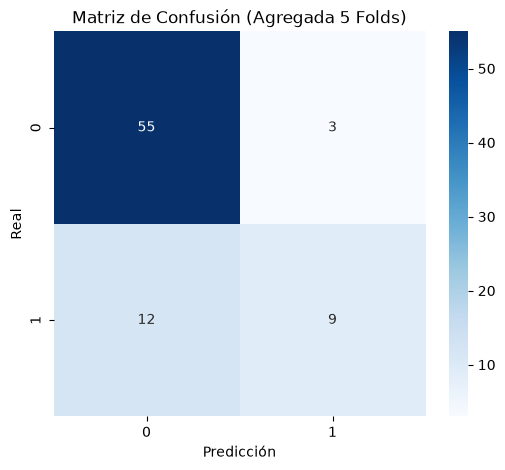

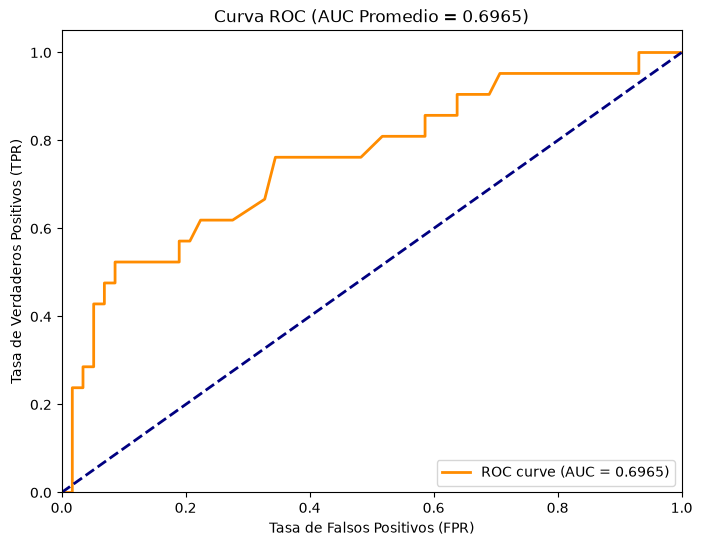

In [7]:
# ==============================================================================
# CELDA: Evaluación Final de ExtraTreesClassifier optimizado
# Pipeline: ExtraTreesClassifier (SIN SMOTE, SIN escalado)
# Embeddings: wav2vec2-large-robust
# Repeticiones: 10 (10 repeticiones x 5 folds = 50 iteraciones)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import auc, make_scorer, f1_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesClassifier

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
EMB_MODEL = "wav2vec2-large-robust"

print(f"\n{'='*80}")
print(f"EVALUACIÓN FINAL (10 repeticiones x 5 folds)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: ExtraTreesClassifier (Parámetros Optimizados)")
print(f"{'='*80}")

try:
    X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, EMB_MODEL, condition=CONDITION)
    X = pd.DataFrame(X_mat)
    y = pd.Series(y_mat)
    print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
except Exception as e:
    print(f"Error cargando los embeddings: {e}")
    sys.exit(1)

# Reutiliza los mejores hiperparámetros hallados por GridSearchCV en la celda anterior
best_clf_params_et = {k.replace('clf__', '', 1): v for k, v in grid_search_et.best_params_.items()}
print(f"Hiperparámetros usados: {best_clf_params_et}")

# Sin StandardScaler ni SMOTE/BorderlineSMOTE — mismo pipeline usado en la búsqueda
pipeline = Pipeline([
    ('clf', ExtraTreesClassifier(random_state=42, **best_clf_params_et))
])

# Configurar Validación Cruzada (10 repeticiones en lugar de 3)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring = {
    'f1_macro': make_scorer(f1_score, average="macro", zero_division=0),
    'accuracy': 'accuracy'
}

# Añadir ROC AUC dependiendo de si es binario o multiclase de forma segura
if len(np.unique(y)) == 2:
    scoring['roc_auc'] = 'roc_auc'
else:
    # ovr se usa para multiclase, asegurando promedios
    scoring['roc_auc'] = 'roc_auc_ovr'

print("\nIniciando Evaluación mediante cross_validate. Esto tomará algunos minutos...")
scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1, verbose=1)

mean_f1 = np.mean(scores['test_f1_macro'])
std_f1 = np.std(scores['test_f1_macro'])
mean_acc = np.mean(scores['test_accuracy'])
std_acc = np.std(scores['test_accuracy'])
mean_roc = np.mean(scores['test_roc_auc'])
std_roc = np.std(scores['test_roc_auc'])

print(f"\n{'='*80}")
print("RESULTADOS FINALES DE LA EVALUACIÓN")
print(f"{'='*80}")
print(f"F1 Macro Promedio: {mean_f1:.4f} (±{std_f1:.4f})")
print(f"Accuracy Promedio:  {mean_acc:.4f} (±{std_acc:.4f})")
print(f"ROC AUC Promedio:   {mean_roc:.4f} (±{std_roc:.4f})")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_predict

print("\nGenerando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...")

# Usamos solo 1 particion de 5 folds para la gráfica representativa y evitar superposición de repeticiones
cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_prob_plot = cross_val_predict(
    pipeline, X, y, cv=cv_plot,
    method='predict_proba', n_jobs=-1
)

classes = np.unique(y)
y_pred_plot = classes[np.argmax(y_prob_plot, axis=1)]

# Matriz de confusion
cm = confusion_matrix(y, y_pred_plot)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión (Agregada 5 Folds)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Curva ROC
plt.figure(figsize=(8, 6))
classes = np.unique(y)

if len(classes) == 2:
    # Binario
    fpr, tpr, _ = roc_curve(y, y_prob_plot[:, 1])
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {mean_roc:.4f})')
else:
    # Multiclase (Uno contra el resto)
    y_bin = label_binarize(y, classes=classes)
    for i, color in zip(range(len(classes)), ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']):
        if i < y_prob_plot.shape[1]:
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_plot[:, i])
            roc_auc_val = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, color=color, label=f'ROC clase {classes[i]} (AUC_fold = {roc_auc_val:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curva ROC (AUC Promedio = {mean_roc:.4f})')
plt.legend(loc="lower right")
plt.show()



EVALUACIÓN FINAL (10 repeticiones x 5 folds)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: ExtraTreesClassifier (Parámetros Optimizados)
Shape de X: (79, 1024), Shape de y: (79,)
Hiperparámetros usados: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Iniciando Evaluación mediante cross_validate. Esto tomará algunos minutos...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 out of  50 | elapsed:    0.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.6s finished



RESULTADOS FINALES DE LA EVALUACIÓN
F1 Macro Promedio: 0.6203 (±0.0996)
Accuracy Promedio:  0.7595 (±0.0574)
ROC AUC Promedio:   0.6965 (±0.1401)

Scores por fold guardados en: scores_evaluacion_final.csv

Generando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...


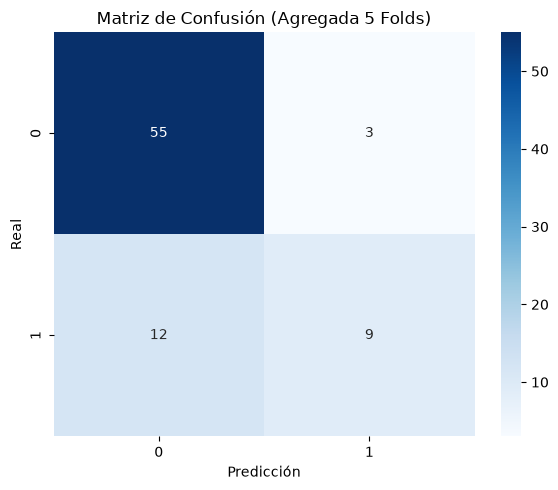

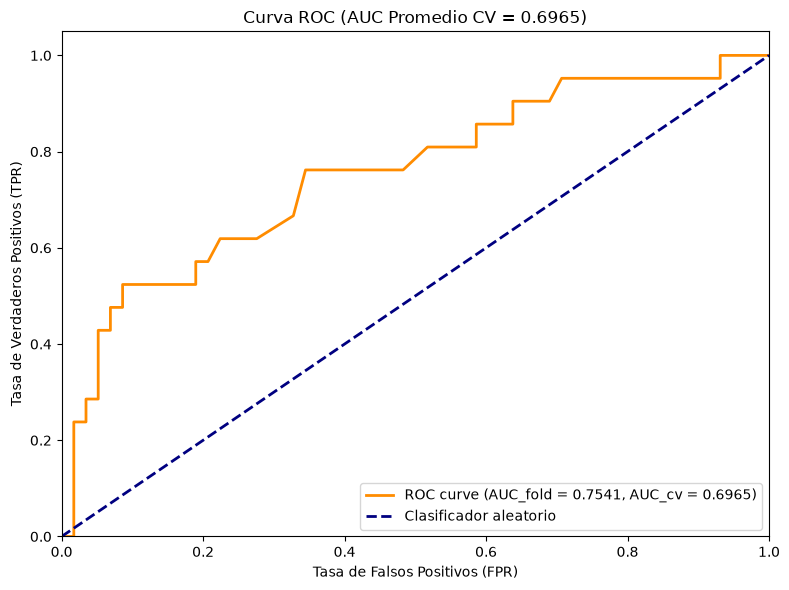

In [8]:
# ==============================================================================
# CELDA: Evaluación Final de ExtraTreesClassifier optimizado
# Pipeline: ExtraTreesClassifier (SIN SMOTE, SIN escalado)
# Embeddings: wav2vec2-large-robust
# Repeticiones: 10 (10 repeticiones x 5 folds = 50 iteraciones)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    make_scorer,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
EMB_MODEL = "wav2vec2-large-robust"
N_SPLITS = 5
N_REPEATS = 10

print(f"\n{'='*80}")
print(f"EVALUACIÓN FINAL ({N_REPEATS} repeticiones x {N_SPLITS} folds)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: ExtraTreesClassifier (Parámetros Optimizados)")
print(f"{'='*80}")

try:
    X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, EMB_MODEL, condition=CONDITION)
    X = pd.DataFrame(X_mat)
    y = pd.Series(y_mat)
    print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
except Exception as e:
    print(f"Error cargando los embeddings: {e}")
    sys.exit(1)

# Reutiliza los mejores hiperparámetros hallados por GridSearchCV en la celda anterior
best_clf_params_et = {k.replace('clf__', '', 1): v for k, v in grid_search_et.best_params_.items()}
print(f"Hiperparámetros usados: {best_clf_params_et}")

# Sin StandardScaler ni SMOTE/BorderlineSMOTE — mismo pipeline usado en la búsqueda
pipeline = Pipeline([
    ('clf', ExtraTreesClassifier(random_state=42, **best_clf_params_et))
])

# Para multiclase se construye un scorer explícito con labels fijos.
classes   = np.unique(y)
is_binary = len(classes) == 2

if is_binary:
    roc_scorer = 'roc_auc'          # sklearn lo resuelve nativamente
else:
    _classes_fixed = classes.tolist()   # lista serializable para multiprocessing

    def _roc_auc_multiclass(y_true, y_prob):
        present = np.unique(y_true)
        if len(present) < len(_classes_fixed):
            return np.nan
        try:
            return roc_auc_score(
                y_true, y_prob,
                average='macro',
                multi_class='ovr',
                labels=_classes_fixed,
            )
        except Exception:
            return np.nan

    roc_scorer = make_scorer(_roc_auc_multiclass, needs_proba=True)

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc':  roc_scorer,
}

# Configurar Validación Cruzada (10 repeticiones x 5 folds)
cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

print("\nIniciando Evaluación mediante cross_validate. Esto tomará algunos minutos...")
scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring,
                        n_jobs=-1, verbose=1, error_score=np.nan)

# ── Diagnóstico: detectar si alguna métrica tiene NaN ────────────────────────
for metric in ('test_f1_macro', 'test_accuracy', 'test_roc_auc'):
    nan_n = np.sum(np.isnan(scores[metric]))
    if nan_n > 0:
        print(f"  ⚠ {metric}: {nan_n}/{len(scores[metric])} folds con NaN")

mean_f1  = np.nanmean(scores['test_f1_macro'])
std_f1   = np.nanstd(scores['test_f1_macro'])
mean_acc = np.nanmean(scores['test_accuracy'])
std_acc  = np.nanstd(scores['test_accuracy'])
mean_roc = np.nanmean(scores['test_roc_auc'])
std_roc  = np.nanstd(scores['test_roc_auc'])

roc_nan_count = np.sum(np.isnan(scores['test_roc_auc']))
total_folds   = len(scores['test_roc_auc'])

print(f"\n{'='*80}")
print("RESULTADOS FINALES DE LA EVALUACIÓN")
print(f"{'='*80}")
print(f"F1 Macro Promedio: {mean_f1:.4f} (±{std_f1:.4f})")
print(f"Accuracy Promedio:  {mean_acc:.4f} (±{std_acc:.4f})")
print(f"ROC AUC Promedio:   {mean_roc:.4f} (±{std_roc:.4f})")
if roc_nan_count > 0:
    print(f"  ⚠ {roc_nan_count}/{total_folds} folds produjeron NaN en ROC AUC "
          f"(clases ausentes en test); excluidos del promedio.")

results_df = pd.DataFrame({
    'fold':      range(1, len(scores['test_f1_macro']) + 1),
    'f1_macro':  scores['test_f1_macro'],
    'accuracy':  scores['test_accuracy'],
    'roc_auc':   scores['test_roc_auc'],
})
results_df.to_csv('scores_evaluacion_final.csv', index=False)
print("\nScores por fold guardados en: scores_evaluacion_final.csv")

# ==============================================================================
# GRÁFICOS: Matriz de Confusión y Curva ROC
# ── loop manual usando StratifiedKFold simple (no hay SMOTE que filtrar) ────
# ==============================================================================
print("\nGenerando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...")

cv_plot    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
y_prob_all = np.zeros((len(y), len(classes)))
y_pred_all = np.empty(len(y), dtype=y.dtype)

for train_idx, test_idx in cv_plot.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train         = y.iloc[train_idx]

    pipeline.fit(X_train, y_train)

    y_prob_all[test_idx] = pipeline.predict_proba(X_test)
    y_pred_all[test_idx] = pipeline.predict(X_test)

# ── Matriz de Confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(y, y_pred_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión (Agregada 5 Folds)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── Curva ROC ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

if is_binary:
    fpr, tpr, _ = roc_curve(y, y_prob_all[:, 1])
    fold_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC_fold = {fold_auc:.4f}, AUC_cv = {mean_roc:.4f})')
else:
    y_bin   = label_binarize(y, classes=classes)
    colors  = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']
    for i, color in zip(range(len(classes)), colors):
        if i < y_prob_all.shape[1]:
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_all[:, i])
            fold_auc     = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, color=color,
                     label=f'ROC clase {classes[i]} (AUC_fold = {fold_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curva ROC (AUC Promedio CV = {mean_roc:.4f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()


In [9]:
# ==============================================================================
# CELDA: Grid Search CV para RandomForestClassifier
# Pipeline: SMOTE (solo train) -> RandomForestClassifier (SIN escalado)
# Este fue el pipeline que obtuvo el mejor ROC AUC (0.6745) para este
# clasificador en la comparación de LazyClassifier (ver celda 2, CON SMOTE)
# Embeddings: wav2vec2-large-robust
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
EMB_MODEL = "wav2vec2-large-robust"

print(f"\n{'='*80}")
print(f"OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: RandomForestClassifier")
print(f"Pipeline: SMOTE (solo train) -> RandomForestClassifier (SIN escalado)")
print(f"{'='*80}")

try:
    X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, EMB_MODEL, condition=CONDITION)
    X = pd.DataFrame(X_mat)
    y = pd.Series(y_mat)
    print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
except Exception as e:
    print(f"Error cargando los embeddings: {e}")
    sys.exit(1)

# Cálculo seguro de vecinos para SMOTE asumiendo 5 folds (queda ~80% en train)
min_samples_in_train = int(y.value_counts().min() * 0.75)
k_safe = max(1, min(5, min_samples_in_train - 1))

# Sin StandardScaler: fue el pipeline que mejor ROC AUC obtuvo para este clasificador
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_safe)),
    ('clf', RandomForestClassifier(random_state=42))
])

# Definir la grilla de hiperparámetros a buscar
param_grid = {
    # Tamaño del bosque — más árboles = más estable
    'clf__n_estimators': [100, 200, 300, 500],

    # El hiperparámetro MÁS influyente en Random Forest
    'clf__max_features': ['sqrt', 'log2', 0.2, 0.3, 0.5, None],

    # Profundidad de los árboles
    'clf__max_depth': [None, 10, 20, 30, 50],

    # Regularización por hoja
    'clf__min_samples_leaf': [1, 2, 3, 5],

    # Split mínimo — interactúa con min_samples_leaf
    'clf__min_samples_split': [2, 5, 10],

    # Pesos de clase — crítico con desbalance
    'clf__class_weight': ['balanced', 'balanced_subsample', None],

    # Criterio de impureza
    'clf__criterion': ['gini', 'entropy'],
}
# 4×6×5×4×3×3×2 = 8,640 combinaciones × 15 folds = 129,600 fits

# Para multiclase se construye un scorer explícito con labels fijos (igual que en la evaluación final).
classes   = np.unique(y)
is_binary = len(classes) == 2

if is_binary:
    roc_scorer = 'roc_auc'          # sklearn lo resuelve nativamente
else:
    _classes_fixed = classes.tolist()   # lista serializable para multiprocessing

    def _roc_auc_multiclass(y_true, y_prob):
        present = np.unique(y_true)
        if len(present) < len(_classes_fixed):
            return np.nan
        try:
            return roc_auc_score(
                y_true, y_prob,
                average='macro',
                multi_class='ovr',
                labels=_classes_fixed,
            )
        except Exception:
            return np.nan

    roc_scorer = make_scorer(_roc_auc_multiclass, needs_proba=True)

scoring = {
    'f1_macro': make_scorer(f1_score, average="macro", zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc':  roc_scorer,
}

# Configurar Validación Cruzada (3 repeticiones en lugar de 10 para agilizar la búsqueda)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

print("\nIniciando GridSearchCV. Esto puede tomar varios minutos de forma silenciosa...")
grid_search_rf = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Optimizar basándose finalmente en ROC AUC
    cv=cv,
    n_jobs=-1,  # Usar todos los procesadores disponibles
    verbose=1,  # Te irá imprimiendo el progreso capa por capa
)

grid_search_rf.fit(X, y)

print(f"\n{'='*80}")
print("RESULTADOS DE LA BÚSQUEDA")
print(f"{'='*80}")
print(f"Mejores Hiperparámetros:\n{grid_search_rf.best_params_}")
print(f"Mejor score de validación (ROC AUC): {grid_search_rf.best_score_:.4f}")

# Extraer el Top 5 de las mejores combinaciones
resultados_cv_rf = pd.DataFrame(grid_search_rf.cv_results_)
top_5_rf = resultados_cv_rf.sort_values(by="rank_test_roc_auc").head(5)

print("\nTop 5 configuraciones de Hiperparámetros:")
for idx, row in top_5_rf.iterrows():
    print(f"\nRank {row['rank_test_roc_auc']}:")
    print(f"  ROC AUC:  {row['mean_test_roc_auc']:.4f} (±{row['std_test_roc_auc']:.4f})")
    print(f"  F1 Macro: {row['mean_test_f1_macro']:.4f} (±{row['std_test_f1_macro']:.4f})")
    print(f"  Accuracy: {row['mean_test_accuracy']:.4f} (±{row['std_test_accuracy']:.4f})")
    print(f"  Parámetros: {row['params']}")



OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: RandomForestClassifier
Pipeline: SMOTE (solo train) -> RandomForestClassifier (SIN escalado)
Shape de X: (79, 1024), Shape de y: (79,)

Iniciando GridSearchCV. Esto puede tomar varios minutos de forma silenciosa...
Fitting 15 folds for each of 8640 candidates, totalling 129600 fits

RESULTADOS DE LA BÚSQUEDA
Mejores Hiperparámetros:
{'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}
Mejor score de validación (ROC AUC): 0.7344

Top 5 configuraciones de Hiperparámetros:

Rank 1:
  ROC AUC:  0.7344 (±0.1101)
  F1 Macro: 0.6572 (±0.1172)
  Accuracy: 0.7592 (±0.0777)
  Parámetros: {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': 50, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_es


EVALUACIÓN FINAL (10 repeticiones x 5 folds)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: RandomForestClassifier (Parámetros Optimizados)
Shape de X: (79, 1024), Shape de y: (79,)
Hiperparámetros usados: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

Iniciando Evaluación mediante cross_validate. Esto tomará algunos minutos...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 out of  50 | elapsed:    1.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    1.5s finished



RESULTADOS FINALES DE LA EVALUACIÓN
F1 Macro Promedio: 0.6401 (±0.1145)
Accuracy Promedio:  0.7459 (±0.0750)
ROC AUC Promedio:   0.6707 (±0.1690)

Scores por fold guardados en: scores_evaluacion_final_rf.csv

Generando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...


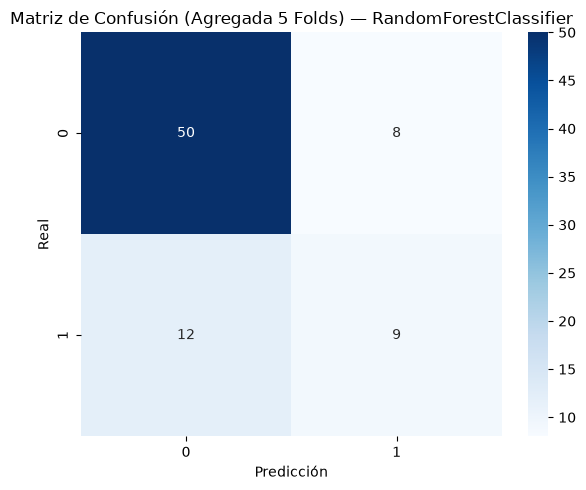

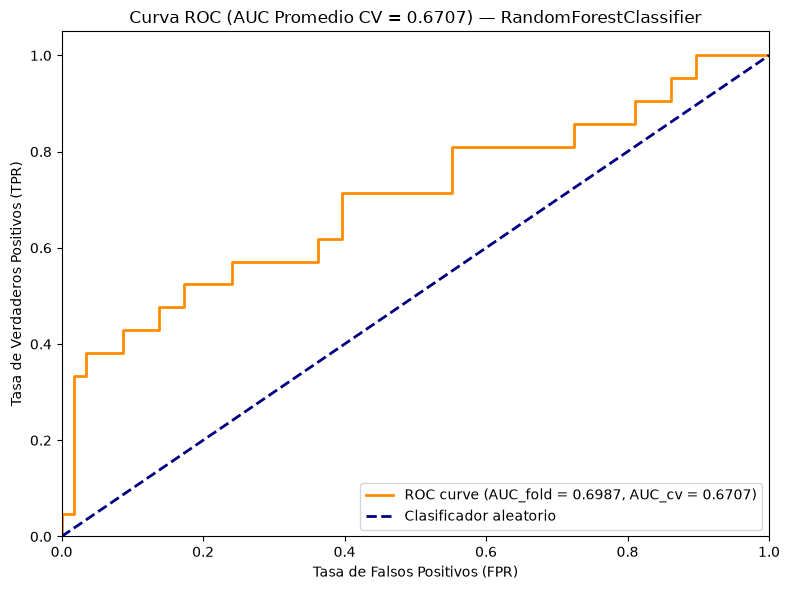

In [10]:
# ==============================================================================
# CELDA: Evaluación Final de RandomForestClassifier optimizado
# Pipeline: SMOTE (solo train) -> RandomForestClassifier (SIN escalado)
# Embeddings: wav2vec2-large-robust
# Repeticiones: 10 (10 repeticiones x 5 folds = 50 iteraciones)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    make_scorer,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
EMB_MODEL = "wav2vec2-large-robust"
N_SPLITS = 5
N_REPEATS = 10

print(f"\n{'='*80}")
print(f"EVALUACIÓN FINAL ({N_REPEATS} repeticiones x {N_SPLITS} folds)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: RandomForestClassifier (Parámetros Optimizados)")
print(f"{'='*80}")

try:
    X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, EMB_MODEL, condition=CONDITION)
    X = pd.DataFrame(X_mat)
    y = pd.Series(y_mat)
    print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
except Exception as e:
    print(f"Error cargando los embeddings: {e}")
    sys.exit(1)

min_samples_in_train = int(y.value_counts().min() * (1 - 1 / N_SPLITS))
k_safe = max(1, min(5, min_samples_in_train - 1))

# Reutiliza los mejores hiperparámetros hallados por GridSearchCV en la celda anterior
best_clf_params_rf = {k.replace('clf__', '', 1): v for k, v in grid_search_rf.best_params_.items()}
print(f"Hiperparámetros usados: {best_clf_params_rf}")

# Sin StandardScaler: mismo pipeline usado en la búsqueda (SMOTE simple, sin escalado)
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_safe)),
    ('clf',   RandomForestClassifier(random_state=42, **best_clf_params_rf)),
])

# Para multiclase se construye un scorer explícito con labels fijos.
classes   = np.unique(y)
is_binary = len(classes) == 2

if is_binary:
    roc_scorer = 'roc_auc'          # sklearn lo resuelve nativamente
else:
    _classes_fixed = classes.tolist()   # lista serializable para multiprocessing

    def _roc_auc_multiclass(y_true, y_prob):
        present = np.unique(y_true)
        if len(present) < len(_classes_fixed):
            return np.nan
        try:
            return roc_auc_score(
                y_true, y_prob,
                average='macro',
                multi_class='ovr',
                labels=_classes_fixed,
            )
        except Exception:
            return np.nan

    roc_scorer = make_scorer(_roc_auc_multiclass, needs_proba=True)

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc':  roc_scorer,
}

# Configurar Validación Cruzada (10 repeticiones x 5 folds)
cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

print("\nIniciando Evaluación mediante cross_validate. Esto tomará algunos minutos...")
scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring,
                        n_jobs=-1, verbose=1, error_score=np.nan)

# ── Diagnóstico: detectar si alguna métrica tiene NaN ────────────────────────
for metric in ('test_f1_macro', 'test_accuracy', 'test_roc_auc'):
    nan_n = np.sum(np.isnan(scores[metric]))
    if nan_n > 0:
        print(f"  ⚠ {metric}: {nan_n}/{len(scores[metric])} folds con NaN")

mean_f1  = np.nanmean(scores['test_f1_macro'])
std_f1   = np.nanstd(scores['test_f1_macro'])
mean_acc = np.nanmean(scores['test_accuracy'])
std_acc  = np.nanstd(scores['test_accuracy'])
mean_roc = np.nanmean(scores['test_roc_auc'])
std_roc  = np.nanstd(scores['test_roc_auc'])

roc_nan_count = np.sum(np.isnan(scores['test_roc_auc']))
total_folds   = len(scores['test_roc_auc'])

print(f"\n{'='*80}")
print("RESULTADOS FINALES DE LA EVALUACIÓN")
print(f"{'='*80}")
print(f"F1 Macro Promedio: {mean_f1:.4f} (±{std_f1:.4f})")
print(f"Accuracy Promedio:  {mean_acc:.4f} (±{std_acc:.4f})")
print(f"ROC AUC Promedio:   {mean_roc:.4f} (±{std_roc:.4f})")
if roc_nan_count > 0:
    print(f"  ⚠ {roc_nan_count}/{total_folds} folds produjeron NaN en ROC AUC "
          f"(clases ausentes en test); excluidos del promedio.")

results_df = pd.DataFrame({
    'fold':      range(1, len(scores['test_f1_macro']) + 1),
    'f1_macro':  scores['test_f1_macro'],
    'accuracy':  scores['test_accuracy'],
    'roc_auc':   scores['test_roc_auc'],
})
results_df.to_csv('scores_evaluacion_final_rf.csv', index=False)
print("\nScores por fold guardados en: scores_evaluacion_final_rf.csv")

# ==============================================================================
# GRÁFICOS: Matriz de Confusión y Curva ROC
# ── loop manual para evitar contaminación por SMOTE ─────────────
# ==============================================================================
print("\nGenerando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...")

cv_plot    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
y_prob_all = np.zeros((len(y), len(classes)))
y_pred_all = np.empty(len(y), dtype=y.dtype)

for train_idx, test_idx in cv_plot.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train         = y.iloc[train_idx]

    pipeline.fit(X_train, y_train)

    y_prob_all[test_idx] = pipeline.predict_proba(X_test)
    y_pred_all[test_idx] = pipeline.predict(X_test)

# ── Matriz de Confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(y, y_pred_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión (Agregada 5 Folds) — RandomForestClassifier')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150)
plt.show()

# ── Curva ROC ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

if is_binary:
    fpr, tpr, _ = roc_curve(y, y_prob_all[:, 1])
    fold_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC_fold = {fold_auc:.4f}, AUC_cv = {mean_roc:.4f})')
else:
    y_bin   = label_binarize(y, classes=classes)
    colors  = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']
    for i, color in zip(range(len(classes)), colors):
        if i < y_prob_all.shape[1]:
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_all[:, i])
            fold_auc     = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, color=color,
                     label=f'ROC clase {classes[i]} (AUC_fold = {fold_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curva ROC (AUC Promedio CV = {mean_roc:.4f}) — RandomForestClassifier')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_rf.png', dpi=150)
plt.show()


In [11]:
# ==============================================================================
# CELDA: Grid Search CV para KNeighborsClassifier
# Pipeline: StandardScaler -> BorderlineSMOTE -> KNeighborsClassifier
# Embeddings: wav2vec2-large-robust
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
EMB_MODEL = "wav2vec2-large-robust"

print(f"\n{'='*80}")
print(f"OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: KNeighborsClassifier")
print(f"Pipeline: StandardScaler -> BorderlineSMOTE -> KNeighborsClassifier")
print(f"{'='*80}")

try:
    X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, EMB_MODEL, condition=CONDITION)
    X = pd.DataFrame(X_mat)
    y = pd.Series(y_mat)
    print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
except Exception as e:
    print(f"Error cargando los embeddings: {e}")
    sys.exit(1)

# Cálculo seguro de vecinos para BorderlineSMOTE asumiendo 5 folds (queda ~80% en train)
min_samples_in_train = int(y.value_counts().min() * 0.75)
k_safe = max(1, min(5, min_samples_in_train - 1))
m_safe = max(1, min(10, min_samples_in_train - 1))

# Construir el Pipeline con ImbPipeline
# (IMPORTANTE: Esto asegura que el SMOTE solo se aplique en el subset de Train de cada Fold internamente)
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', BorderlineSMOTE(random_state=42, k_neighbors=k_safe, m_neighbors=m_safe)),
    ('clf', KNeighborsClassifier())
])

# Definir la grilla de hiperparámetros a buscar
param_grid = {
    # Número de vecinos — el hiperparámetro más influyente en KNN
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],

    # Ponderación por distancia suele ayudar cuando las clases están desbalanceadas
    'clf__weights': ['uniform', 'distance'],

    # Métrica de distancia sobre el espacio de embeddings
    'clf__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],
}
# 8×2×4 = 64 combinaciones × 15 folds = 960 fits

# Para multiclase se construye un scorer explícito con labels fijos (igual que en la evaluación final).
classes   = np.unique(y)
is_binary = len(classes) == 2

if is_binary:
    roc_scorer = 'roc_auc'          # sklearn lo resuelve nativamente
else:
    _classes_fixed = classes.tolist()   # lista serializable para multiprocessing

    def _roc_auc_multiclass(y_true, y_prob):
        present = np.unique(y_true)
        if len(present) < len(_classes_fixed):
            return np.nan
        try:
            return roc_auc_score(
                y_true, y_prob,
                average='macro',
                multi_class='ovr',
                labels=_classes_fixed,
            )
        except Exception:
            return np.nan

    roc_scorer = make_scorer(_roc_auc_multiclass, needs_proba=True)

scoring = {
    'f1_macro': make_scorer(f1_score, average="macro", zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc':  roc_scorer,
}

# Configurar Validación Cruzada (3 repeticiones en lugar de 10 para agilizar la búsqueda)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

print("\nIniciando GridSearchCV. Esto puede tomar varios minutos de forma silenciosa...")
grid_search_knn = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Optimizar basándose finalmente en ROC AUC
    cv=cv,
    n_jobs=-1,  # Usar todos los procesadores disponibles
    verbose=1,  # Te irá imprimiendo el progreso capa por capa
)

grid_search_knn.fit(X, y)

print(f"\n{'='*80}")
print("RESULTADOS DE LA BÚSQUEDA")
print(f"{'='*80}")
print(f"Mejores Hiperparámetros:\n{grid_search_knn.best_params_}")
print(f"Mejor score de validación (ROC AUC): {grid_search_knn.best_score_:.4f}")

# Extraer el Top 5 de las mejores combinaciones
resultados_cv_knn = pd.DataFrame(grid_search_knn.cv_results_)
top_5_knn = resultados_cv_knn.sort_values(by="rank_test_roc_auc").head(5)

print("\nTop 5 configuraciones de Hiperparámetros:")
for idx, row in top_5_knn.iterrows():
    print(f"\nRank {row['rank_test_roc_auc']}:")
    print(f"  ROC AUC:  {row['mean_test_roc_auc']:.4f} (±{row['std_test_roc_auc']:.4f})")
    print(f"  F1 Macro: {row['mean_test_f1_macro']:.4f} (±{row['std_test_f1_macro']:.4f})")
    print(f"  Accuracy: {row['mean_test_accuracy']:.4f} (±{row['std_test_accuracy']:.4f})")
    print(f"  Parámetros: {row['params']}")



OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: KNeighborsClassifier
Pipeline: StandardScaler -> BorderlineSMOTE -> KNeighborsClassifier
Shape de X: (79, 1024), Shape de y: (79,)

Iniciando GridSearchCV. Esto puede tomar varios minutos de forma silenciosa...
Fitting 15 folds for each of 64 candidates, totalling 960 fits

RESULTADOS DE LA BÚSQUEDA
Mejores Hiperparámetros:
{'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Mejor score de validación (ROC AUC): 0.7299

Top 5 configuraciones de Hiperparámetros:

Rank 1:
  ROC AUC:  0.7299 (±0.0910)
  F1 Macro: 0.6289 (±0.0812)
  Accuracy: 0.6661 (±0.0800)
  Parámetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__weights': 'distance'}

Rank 2:
  ROC AUC:  0.7282 (±0.0926)
  F1 Macro: 0.6287 (±0.1230)
  Accuracy: 0.6581 (±0.1295)
  Parámetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 5, 'clf__weights': 'distance'}

Rank 3:
  ROC AUC:  


EVALUACIÓN FINAL (10 repeticiones x 5 folds)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: KNeighborsClassifier (Parámetros Optimizados)
Shape de X: (79, 1024), Shape de y: (79,)
Hiperparámetros usados: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

Iniciando Evaluación mediante cross_validate. Esto tomará algunos minutos...

RESULTADOS FINALES DE LA EVALUACIÓN
F1 Macro Promedio: 0.5893 (±0.1241)
Accuracy Promedio:  0.6305 (±0.1172)
ROC AUC Promedio:   0.6675 (±0.1678)

Scores por fold guardados en: scores_evaluacion_final_knn.csv

Generando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 out of  50 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.1s finished


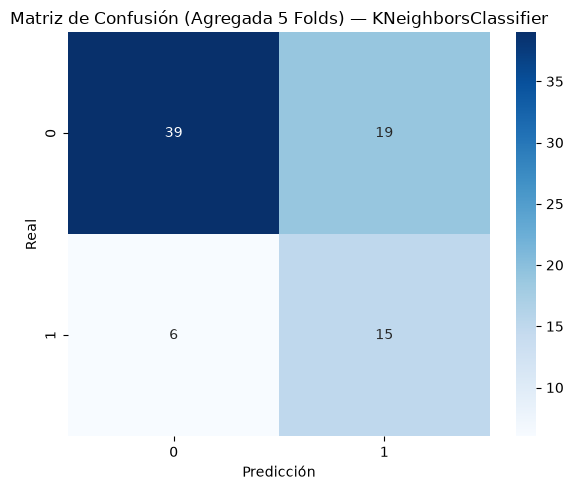

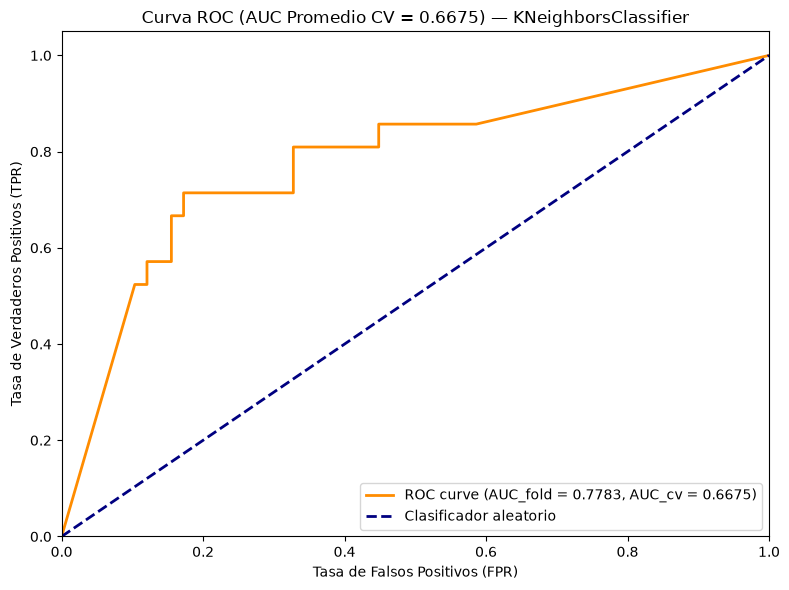

In [12]:
# ==============================================================================
# CELDA: Evaluación Final de KNeighborsClassifier optimizado
# Pipeline: StandardScaler -> BorderlineSMOTE -> KNeighborsClassifier
# Embeddings: wav2vec2-large-robust
# Repeticiones: 10 (10 repeticiones x 5 folds = 50 iteraciones)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    make_scorer,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2/"
CONDITION = "depresion"
EMB_MODEL = "wav2vec2-large-robust"
N_SPLITS = 5
N_REPEATS = 10

print(f"\n{'='*80}")
print(f"EVALUACIÓN FINAL ({N_REPEATS} repeticiones x {N_SPLITS} folds)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: KNeighborsClassifier (Parámetros Optimizados)")
print(f"{'='*80}")

try:
    X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, EMB_MODEL, condition=CONDITION)
    X = pd.DataFrame(X_mat)
    y = pd.Series(y_mat)
    print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
except Exception as e:
    print(f"Error cargando los embeddings: {e}")
    sys.exit(1)

min_samples_in_train = int(y.value_counts().min() * (1 - 1 / N_SPLITS))
k_safe = max(1, min(5, min_samples_in_train - 1))
m_safe = max(1, min(10, min_samples_in_train - 1))

# Reutiliza los mejores hiperparámetros hallados por GridSearchCV en la celda anterior
best_clf_params_knn = {k.replace('clf__', '', 1): v for k, v in grid_search_knn.best_params_.items()}
print(f"Hiperparámetros usados: {best_clf_params_knn}")

# Construir el Pipeline con los mejores hiperparámetros encontrados
# (KNeighborsClassifier no acepta random_state)
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  BorderlineSMOTE(random_state=42, k_neighbors=k_safe, m_neighbors=m_safe)),
    ('clf',    KNeighborsClassifier(**best_clf_params_knn)),
])

# Para multiclase se construye un scorer explícito con labels fijos.
classes   = np.unique(y)
is_binary = len(classes) == 2

if is_binary:
    roc_scorer = 'roc_auc'          # sklearn lo resuelve nativamente
else:
    _classes_fixed = classes.tolist()   # lista serializable para multiprocessing

    def _roc_auc_multiclass(y_true, y_prob):
        present = np.unique(y_true)
        if len(present) < len(_classes_fixed):
            return np.nan
        try:
            return roc_auc_score(
                y_true, y_prob,
                average='macro',
                multi_class='ovr',
                labels=_classes_fixed,
            )
        except Exception:
            return np.nan

    roc_scorer = make_scorer(_roc_auc_multiclass, needs_proba=True)

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc':  roc_scorer,
}

# Configurar Validación Cruzada (10 repeticiones x 5 folds)
cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

print("\nIniciando Evaluación mediante cross_validate. Esto tomará algunos minutos...")
scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring,
                        n_jobs=-1, verbose=1, error_score=np.nan)

# ── Diagnóstico: detectar si alguna métrica tiene NaN ────────────────────────
for metric in ('test_f1_macro', 'test_accuracy', 'test_roc_auc'):
    nan_n = np.sum(np.isnan(scores[metric]))
    if nan_n > 0:
        print(f"  ⚠ {metric}: {nan_n}/{len(scores[metric])} folds con NaN")

mean_f1  = np.nanmean(scores['test_f1_macro'])
std_f1   = np.nanstd(scores['test_f1_macro'])
mean_acc = np.nanmean(scores['test_accuracy'])
std_acc  = np.nanstd(scores['test_accuracy'])
mean_roc = np.nanmean(scores['test_roc_auc'])
std_roc  = np.nanstd(scores['test_roc_auc'])

roc_nan_count = np.sum(np.isnan(scores['test_roc_auc']))
total_folds   = len(scores['test_roc_auc'])

print(f"\n{'='*80}")
print("RESULTADOS FINALES DE LA EVALUACIÓN")
print(f"{'='*80}")
print(f"F1 Macro Promedio: {mean_f1:.4f} (±{std_f1:.4f})")
print(f"Accuracy Promedio:  {mean_acc:.4f} (±{std_acc:.4f})")
print(f"ROC AUC Promedio:   {mean_roc:.4f} (±{std_roc:.4f})")
if roc_nan_count > 0:
    print(f"  ⚠ {roc_nan_count}/{total_folds} folds produjeron NaN en ROC AUC "
          f"(clases ausentes en test); excluidos del promedio.")

results_df = pd.DataFrame({
    'fold':      range(1, len(scores['test_f1_macro']) + 1),
    'f1_macro':  scores['test_f1_macro'],
    'accuracy':  scores['test_accuracy'],
    'roc_auc':   scores['test_roc_auc'],
})
results_df.to_csv('scores_evaluacion_final_knn.csv', index=False)
print("\nScores por fold guardados en: scores_evaluacion_final_knn.csv")

# ==============================================================================
# GRÁFICOS: Matriz de Confusión y Curva ROC
# ── loop manual para evitar contaminación por SMOTE ─────────────
# ==============================================================================
print("\nGenerando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...")

cv_plot    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
y_prob_all = np.zeros((len(y), len(classes)))
y_pred_all = np.empty(len(y), dtype=y.dtype)

for train_idx, test_idx in cv_plot.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train         = y.iloc[train_idx]

    pipeline.fit(X_train, y_train)

    y_prob_all[test_idx] = pipeline.predict_proba(X_test)
    y_pred_all[test_idx] = pipeline.predict(X_test)

# ── Matriz de Confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(y, y_pred_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión (Agregada 5 Folds) — KNeighborsClassifier')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix_knn.png', dpi=150)
plt.show()

# ── Curva ROC ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

if is_binary:
    fpr, tpr, _ = roc_curve(y, y_prob_all[:, 1])
    fold_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC_fold = {fold_auc:.4f}, AUC_cv = {mean_roc:.4f})')
else:
    y_bin   = label_binarize(y, classes=classes)
    colors  = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']
    for i, color in zip(range(len(classes)), colors):
        if i < y_prob_all.shape[1]:
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_all[:, i])
            fold_auc     = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, color=color,
                     label=f'ROC clase {classes[i]} (AUC_fold = {fold_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curva ROC (AUC Promedio CV = {mean_roc:.4f}) — KNeighborsClassifier')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_knn.png', dpi=150)
plt.show()
